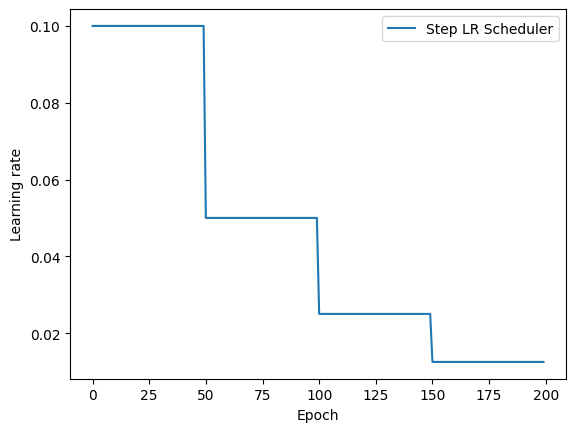

In [4]:
import torch
from torch import optim
import matplotlib.pyplot as plt


def test_lr():
    LR = 0.1  # 设置初始化学习率为0.1
    iteration = 10  # 每个epoch迭代10次
    max_epoch = 200  # 训练轮次
    # 1 初始化参数
    y_true = torch.tensor([0])
    x = torch.tensor([1.0])
    w = torch.tensor([1.0], requires_grad=True)
    # 2.优化器
    optimizer = optim.SGD([w], lr=LR, momentum=0.9)
    # 3.设置学习率下降策略
    #   step_size：调整间隔数=50
    #   gamma：调整系数=0.5
    #   调整方式：lr = lr * gamma
    scheduler_lr = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
    # 4.获取学习率的值和当前的epoch
    lr_list, epoch_list = [], []
    for epoch in range(max_epoch):
        lr_list.append(scheduler_lr.get_last_lr())  # 获取当前学习率
        epoch_list.append(epoch)
        for i in range(iteration):
            loss = (w * x - y_true) ** 2
            optimizer.zero_grad()
            # 反向传播
            loss.backward()
            optimizer.step()
        # 更新下一个epoch的学习率
        scheduler_lr.step()
    # 5.绘制学习率变化的曲线
    plt.plot(epoch_list, lr_list, label="Step LR Scheduler")
    plt.xlabel("Epoch")
    plt.ylabel("Learning rate")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    test_lr()